In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
p = plt.rcParams  # 获取默认绘图参数
p["font.weight"] = "light"  # 设置字体粗细为 light
p["ytick.minor.visible"] = True  # 显示 y 轴的小刻度
p["xtick.minor.visible"] = True  # 显示 x 轴的小刻度
p["axes.grid"] = True  # 启用坐标轴网格
p["grid.color"] = "0.5"  # 设置网格颜色为灰色
p["grid.linewidth"] = 0.5  # 设置网格线宽度

In [11]:
def plot_stem(df,column):
    #第一个方法计算每个值出现次数(降序),返回Series,第二个转为df,第三个变为升序
    pmf_df = df[column].value_counts().to_frame().sort_index() / len(df)
    fig,ax = plt.subplots()
    #之前的数据,变为df后,series的记数的columnname变为'count'
    #.index取出索引,之前的不重复的值,类型看存进来是什么类型
    centroid = np.sum(pmf_df['count'] * pmf_df.index) #计算均值
    plt.stem(pmf_df.index,pmf_df['count'].astype(float))
    plt.vlines(centroid, 0, 0.3, colors='r', linestyles='--') # 绘制质心的垂线
    plt.ylim(0, 0.3) # 设置y轴范围
    plt.xlim(-5, 40) # 设置x轴范围
    plt.ylabel('Probability, PMF') # 设置y轴标签
    plt.title(column + '; average = ' + '{0:.2f}'.format(centroid)) # 设置标题

In [6]:
def plot_contour(XX1,XX2,df,column,XX1_fine,XX2_fine,YY):
    XX1_ = XX1.ravel()
    XX2_ = XX2.ravel()
    #sort进行排序,升序排序
    levels = np.sort(df[column].unique()) #unique去重
    print(list(levels))
    fig,ax = plt.subplots()
    plt.scatter(XX1_,XX2_)
    CS = plt.contour(XX1_fine,XX2_fine,YY,levels = levels,cmap = 'rainbow')
    ax.clabel(CS,inline = True,fontsize = 12,fmt = '%.2f')
    ax.set_aspect('equal',adjustable = 'box')
    plt.grid(True)
    plt.xlim(1 - 0.5, 6 + 0.5) # 设置x轴范围
    plt.ylim(1 - 0.5, 6 + 0.5) # 设置y轴范围
    ax.spines['top'].set_visible(False) # 隐藏顶部边框
    ax.spines['right'].set_visible(False) # 隐藏右侧边框
    ax.spines['bottom'].set_visible(False) # 隐藏底部边框
    ax.spines['left'].set_visible(False) # 隐藏左侧边框
    ax.tick_params(axis="y", direction='in', length=8) # 设置y轴刻度方向
    ax.tick_params(axis="x", direction='in', length=8) # 设置x轴刻度方向
    plt.xlabel('$X_1$') # 设置x轴标签
    plt.ylabel('$X_2$') # 设置y轴标签
    plt.title(column) # 设置标题

In [26]:
X1_array = np.arange(1,6+1)
X2_array = np.arange(1,6+1)

X1_fine_array = np.linspace(0.5,6.5,100)
X2_fine_array = np.linspace(0.5,6.5,100)

XX1,XX2 = np.meshgrid(X1_array,X2_array)
#fine是精细的意思
XX1_fine,XX2_fine = np.meshgrid(X1_fine_array,X2_fine_array)

XX1_ = XX1.ravel()
XX2_ = XX2.ravel()

df = pd.DataFrame(np.column_stack((XX1_,XX2_)),columns =['X1','X2'])

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


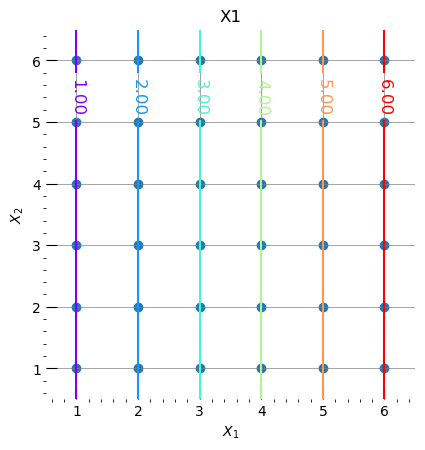

In [27]:
YY_X1_only = XX1_fine
plot_contour(XX1,XX2,df,'X1',XX1_fine,XX2_fine,YY_X1_only)

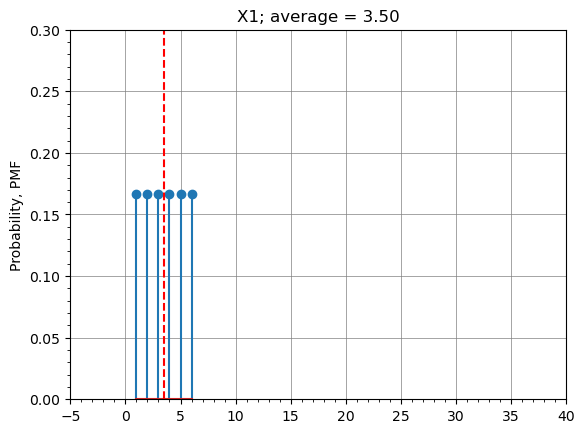

In [28]:
plot_stem(df,'X1')

[np.int64(1), np.int64(4), np.int64(9), np.int64(16), np.int64(25), np.int64(36)]


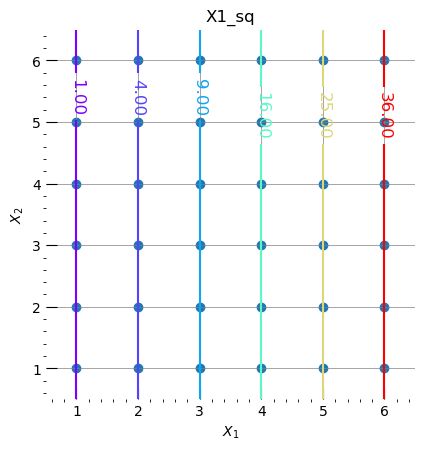

In [29]:
df['X1_sq'] = df['X1'] ** 2
YY_X1_sq = XX1_fine**2
plot_contour(XX1,XX2,df,'X1_sq',XX1_fine,XX2_fine,YY_X1_sq)

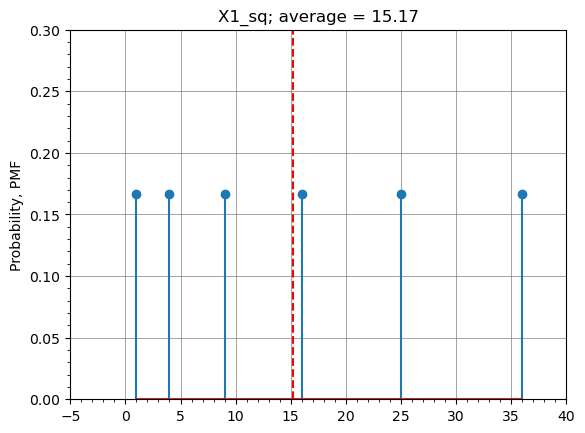

In [30]:
plot_stem(df,'X1_sq')

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


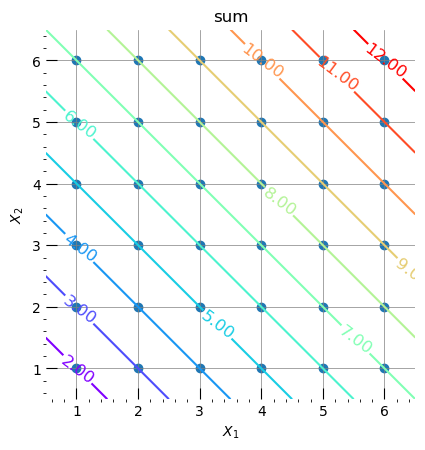

In [31]:
df['sum'] = (df['X1'] + df['X2'])
YY_sum = XX1_fine + XX2_fine
plot_contour(XX1,XX2,df,'sum',XX1_fine,XX2_fine,YY_sum)

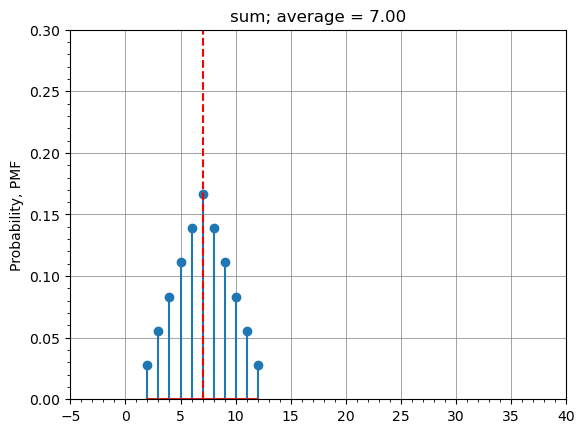

In [32]:
plot_stem(df,'sum')

[np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0), np.float64(5.5), np.float64(6.0)]


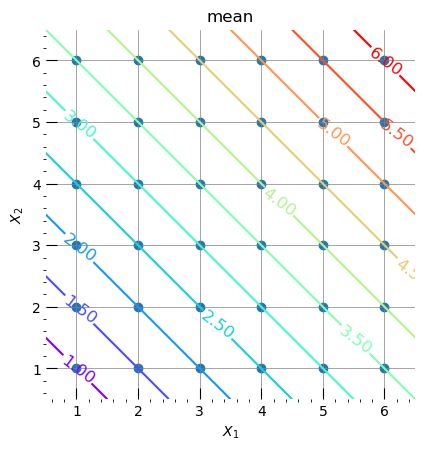

In [34]:
df['mean'] = (df['X1'] + df['X2']) / 2
YY_mean = (XX1_fine + XX2_fine) / 2
plot_contour(XX1,XX2,df,'mean',XX1_fine,XX2_fine,YY_mean)

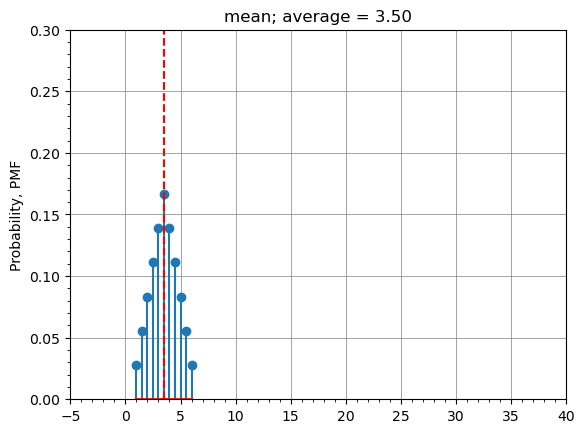

In [35]:
plot_stem(df,'mean')

[np.float64(-2.5), np.float64(-2.0), np.float64(-1.5), np.float64(-1.0), np.float64(-0.5), np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5)]


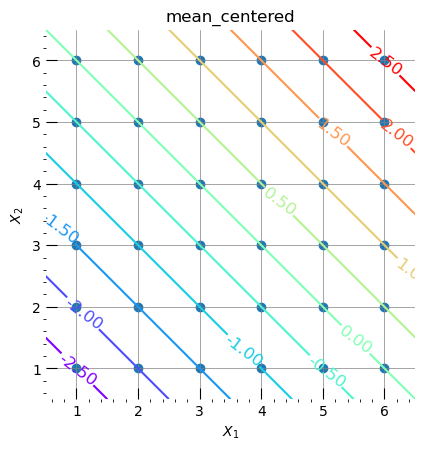

In [39]:
df['mean_centered'] = (df['X1'] + df['X2'] - 7) / 2
YY_mean_centered = (XX1_fine + XX2_fine - 7) / 2
plot_contour(XX1,XX2,df,'mean_centered',XX1_fine,XX2_fine,YY_mean_centered)

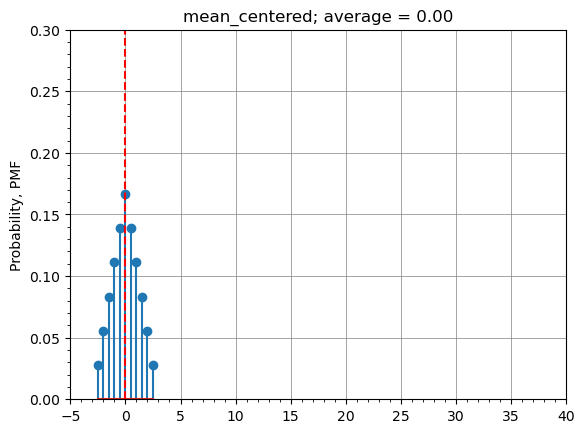

In [40]:
plot_stem(df,'mean_centered')

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(15), np.int64(16), np.int64(18), np.int64(20), np.int64(24), np.int64(25), np.int64(30), np.int64(36)]


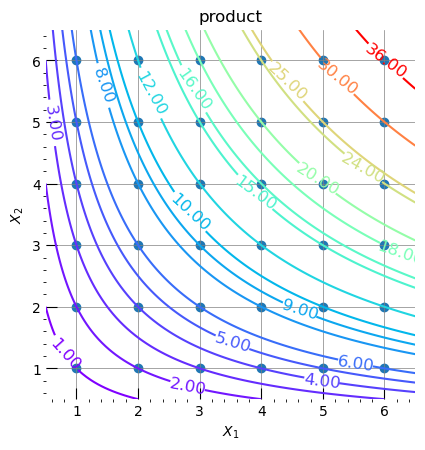

In [41]:
df['product'] = df['X1'] * df['X2']
YY_product = XX1_fine * XX2_fine
plot_contour(XX1,XX2,df,'product',XX1_fine,XX2_fine,YY_product)

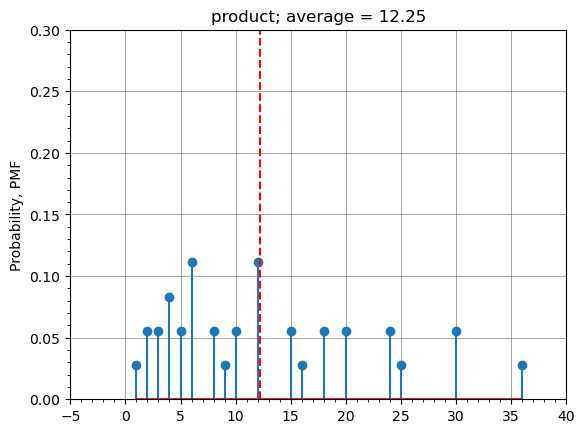

In [42]:
plot_stem(df,'product')

[np.float64(0.16666666666666666), np.float64(0.2), np.float64(0.25), np.float64(0.3333333333333333), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.6666666666666666), np.float64(0.75), np.float64(0.8), np.float64(0.8333333333333334), np.float64(1.0), np.float64(1.2), np.float64(1.25), np.float64(1.3333333333333333), np.float64(1.5), np.float64(1.6666666666666667), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]


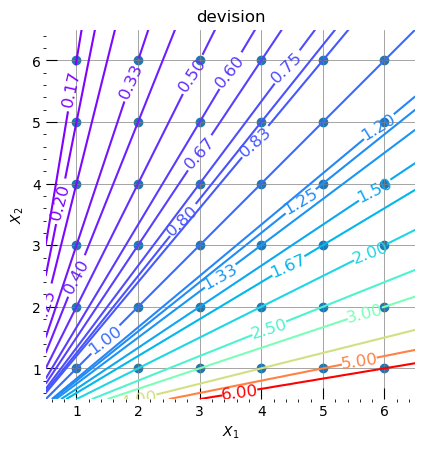

In [43]:
df['devision'] = df['X1'] / df['X2']
YY_devision = XX1_fine / XX2_fine
plot_contour(XX1,XX2,df,'devision',XX1_fine,XX2_fine,YY_devision)

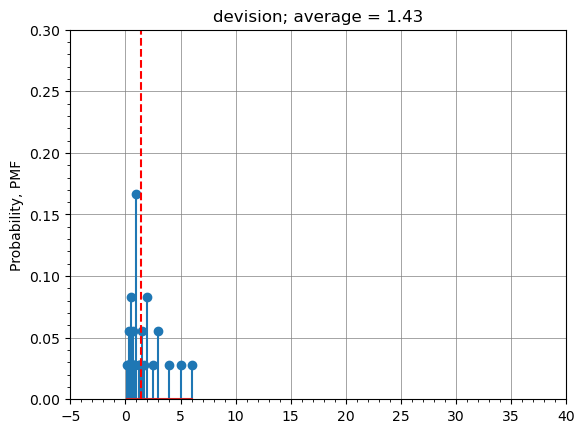

In [44]:
plot_stem(df,'devision')

[np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


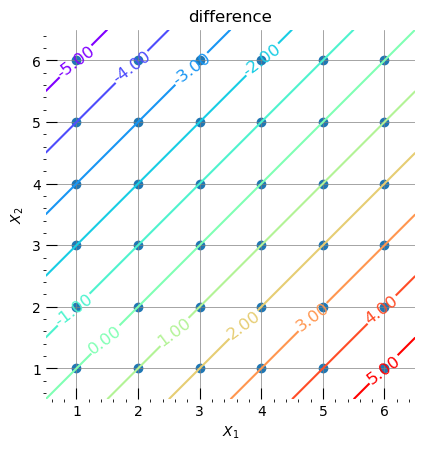

In [45]:
df['difference'] = df['X1'] - df['X2']
YY_difference = XX1_fine - XX2_fine
plot_contour(XX1,XX2,df,'difference',XX1_fine,XX2_fine,YY_difference)

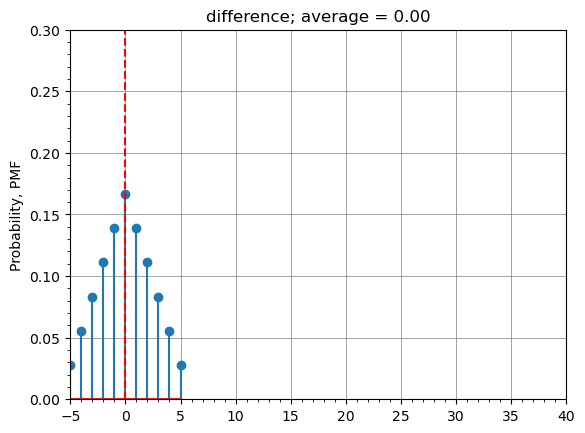

In [46]:
plot_stem(df,'difference')

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


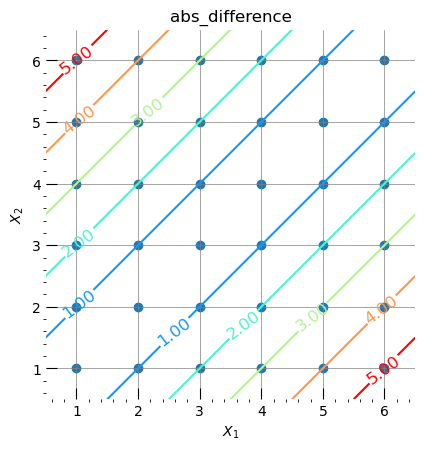

In [47]:
df['abs_difference'] = np.abs(df['X1'] - df['X2'])
YY_abs_difference = np.abs(XX1_fine - XX2_fine)
plot_contour(XX1,XX2,df,'abs_difference',XX1_fine,XX2_fine,YY_abs_difference)

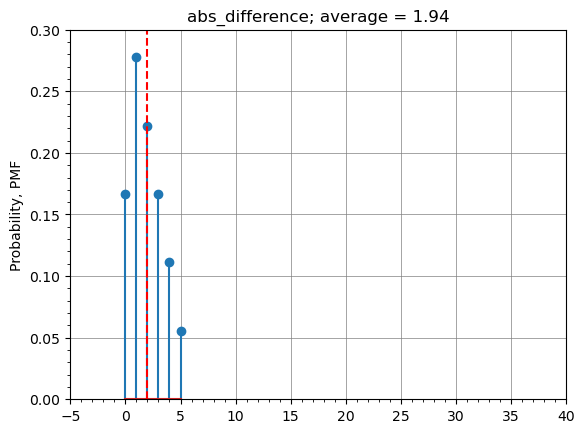

In [48]:
plot_stem(df,'abs_difference')

[np.float64(0.5), np.float64(2.5), np.float64(4.5), np.float64(6.5), np.float64(8.5), np.float64(12.5)]


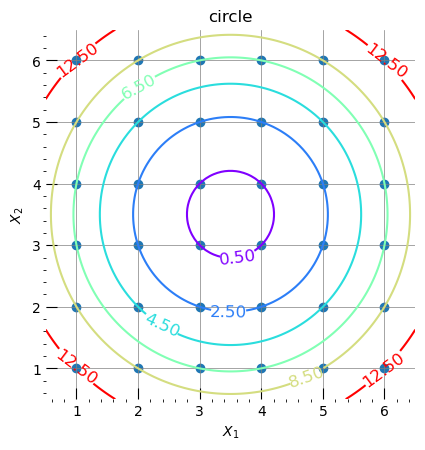

In [50]:
df['circle'] = (df['X1'] - 3.5) ** 2 + (df['X2'] - 3.5)**2
YY_circle = (XX1_fine - 3.5) **2 + (XX2_fine - 3.5) **2 
plot_contour(XX1,XX2,df,'circle',XX1_fine,XX2_fine,YY_circle)

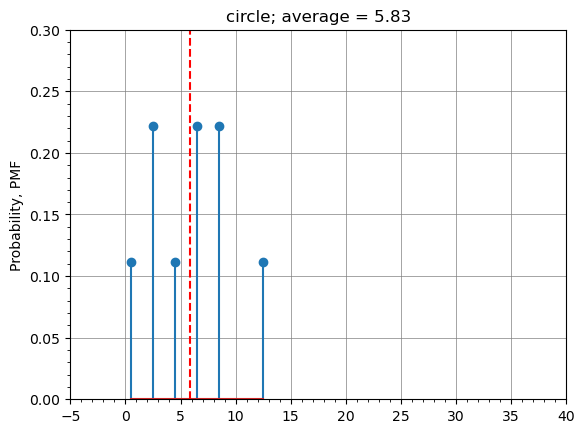

In [51]:
plot_stem(df,'circle')

In [52]:
import numpy as np

In [53]:
E_X_2 = 0.007*4.5 + 0.073*4.0 + 0.21*3.5 + 0.49*3.0 + 0.19 * 2.5 + 0.027*2.0

In [56]:
E_X_2_2 = 0.007*np.square(4.5) + 0.073*np.square(4.0) + 0.21*np.square(3.5) + 0.49*np.square(3.0) + 0.19 * np.square(2.5) + 0.027*np.square(2.0)

In [57]:
var_X_2 = E_X_2_2 - np.square(E_X_2)

In [58]:
var_X_2

np.float64(0.2394437499999995)

In [59]:
var_X_2_st = np.sqrt(var_X_2)
var_X_2_st

np.float64(0.48932989894344237)